In [12]:
import matplotlib.pyplot as plt
import numpy as np
from chemlab.util.unit import ENERGY

In [13]:
e1 = np.load("full_energy.npy")
e1 = e1.reshape(-1)
e1 = ENERGY(e1,"hartree").convert_to("kcal")

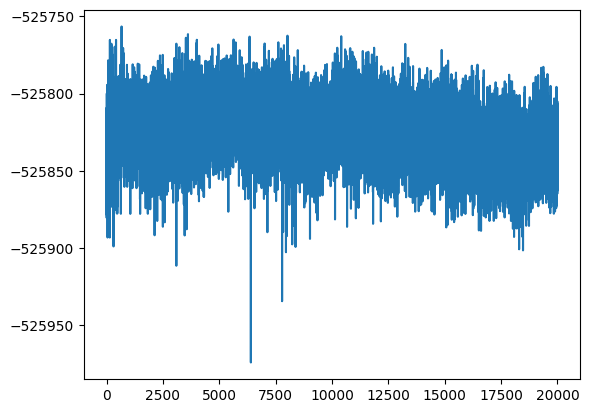

In [14]:
plt.plot(e1)

In [15]:
e2 = np.load("full_energy2.npy")
e2 = e2.reshape(-1)

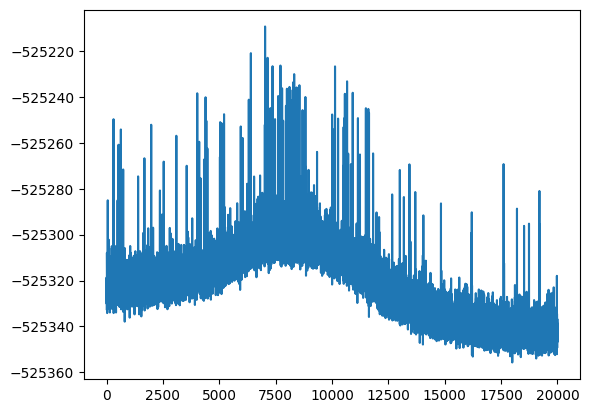

In [16]:
plt.plot(e2)


from chemlab.util.
tem_qmout = qchem_file()
tem_qmout.molecule.check = True
tem_qmout.external_charges.check = True
tem_qmout.read_file(f"{qmmmpath}/{00}//{0000}/{prefix}{0000}.inp")
tem_qm_coord = tem_qmout.molecule.xyz
tem_mm_coord = tem_qmout.external_charges.mm_pos

In [22]:
from chemlab.util.file_system import qchem_file
import numpy as np
tem_qmout = qchem_file()
tem_qmout.molecule.check = True
tem_qmout.external_charges.check = True
tem_qmout.read_file(f"qmmm_0000.inp")
tem_qm_coord = np.array(tem_qmout.molecule.xyz).astype(float)
tem_mm_coord = np.array(tem_qmout.external_charges.mm_pos).astype(float)

In [23]:
tem_qm_coord.shape,tem_mm_coord.shape
tem_coords = np.vstack((tem_qm_coord,tem_mm_coord))

In [31]:
cutoff = 10
idx_list = []
for i in range(len(tem_mm_coord)):
    for j in range(len(tem_qm_coord)):
        dis = np.linalg.norm(tem_mm_coord[i] - tem_qm_coord[j])
        if dis < cutoff and i not in idx_list:
            idx_list.append(i)


In [32]:
idx_list = np.array(idx_list)

In [33]:
idx_list.shape

(895,)

In [34]:
from scipy.spatial import cKDTree
tree = cKDTree(tem_mm_coord)
qm_tree = cKDTree(tem_qm_coord)

idx_set = tree.query_ball_tree(qm_tree, r=cutoff)
idx_list = sorted(set(i for i, hits in enumerate(idx_set) if hits))

In [37]:
idx_list = np.array(idx_list)
idx_list.shape

(895,)

In [39]:
tem_mm_coord[idx_list].shape

(895, 3)

In [41]:
import pypdf

In [42]:
from pypdf import PdfReader, PdfWriter

reader = PdfReader("CSAPP_2016.pdf")

def split_pdf(reader, start, end, output_path):
    writer = PdfWriter()
    for i in range(start, end):
        writer.add_page(reader.pages[i])
    with open(output_path, "wb") as f:
        writer.write(f)

# 拆成每30页一份
chunk_size = 30
total = len(reader.pages)

for i in range(0, total, chunk_size):
    end = min(i + chunk_size, total)
    split_pdf(reader, i, end, f"part_{i//chunk_size + 1}.pdf")
    print(f"已生成 part_{i//chunk_size + 1}.pdf（第{i+1}-{end}页）")

已生成 part_1.pdf（第1-30页）
已生成 part_2.pdf（第31-60页）
已生成 part_3.pdf（第61-90页）
已生成 part_4.pdf（第91-120页）
已生成 part_5.pdf（第121-150页）
已生成 part_6.pdf（第151-180页）
已生成 part_7.pdf（第181-210页）
已生成 part_8.pdf（第211-240页）
已生成 part_9.pdf（第241-270页）
已生成 part_10.pdf（第271-300页）
已生成 part_11.pdf（第301-330页）
已生成 part_12.pdf（第331-360页）
已生成 part_13.pdf（第361-390页）
已生成 part_14.pdf（第391-420页）
已生成 part_15.pdf（第421-450页）
已生成 part_16.pdf（第451-480页）
已生成 part_17.pdf（第481-510页）
已生成 part_18.pdf（第511-540页）
已生成 part_19.pdf（第541-570页）
已生成 part_20.pdf（第571-600页）
已生成 part_21.pdf（第601-630页）
已生成 part_22.pdf（第631-660页）
已生成 part_23.pdf（第661-690页）
已生成 part_24.pdf（第691-720页）
已生成 part_25.pdf（第721-750页）
已生成 part_26.pdf（第751-780页）
已生成 part_27.pdf（第781-810页）
已生成 part_28.pdf（第811-840页）
已生成 part_29.pdf（第841-870页）
已生成 part_30.pdf（第871-900页）
已生成 part_31.pdf（第901-930页）
已生成 part_32.pdf（第931-960页）
已生成 part_33.pdf（第961-990页）
已生成 part_34.pdf（第991-1020页）
已生成 part_35.pdf（第1021-1050页）
已生成 part_36.pdf（第1051-1080页）
已生成 part_37.pdf（第1081-1105页）
